In [1]:
# from netCDF4 import Dataset as NetCDFFile
# import xarray as xr
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [5]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def array_centered(file_name, lat, lon, window_size=16):
    # Open the file
    ds = xr.open_dataset(file_name)
    # Get the lat, lon, xco2 array
    lats = ds['lat'].values
    lons = ds['lon'].values
    xco2 = ds['XCO2'].values
    # Find the index of the nearest lat and lon
    lat_idx = find_nearest(lats, lat)
    lon_idx = find_nearest(lons, lon)
    # Get the window of data
    window = xco2[0, lat_idx-window_size:lat_idx+window_size, lon_idx-window_size:lon_idx+window_size]
    return window

def get_dates(start_date, end_date):
    # Get the start and end dates
    start = datetime.strptime(start_date, '%Y%m%d')
    end = datetime.strptime(end_date, '%Y%m%d')
    # Get filename
    current_date = start_date
    filename = '../../OCO-2/oco2_GEOS_L3CO2_day_{}_B10206Ar.nc4'.format(current_date)
    file_list = [[filename, current_date]]
    # Get the list of names
    while current_date != end_date:
        current_date_timestep = datetime.strptime(current_date, '%Y%m%d')
        current_date = (current_date_timestep + timedelta(days=1)).strftime('%Y%m%d')
        filename = '../../OCO-2/oco2_GEOS_L3CO2_day_{}_B10206Ar.nc4'.format(current_date)
        file_list.append([filename, current_date])
    return file_list

In [6]:
file = xr.open_dataset('../../OCO-2/oco2_GEOS_L3CO2_day_20150102_B10206Ar.nc4')
filename = '../../OCO-2/oco2_GEOS_L3CO2_day_20150102_B10206Ar.nc4'
xco2 = file['XCO2'].values
lat = file['lat'].values
array_centered(filename, -16.167428, 33.661022).shape

for item in get_dates('20150102', '20150105'):
    print(item[0])
    print(item[1])

../../OCO-2/oco2_GEOS_L3CO2_day_20150102_B10206Ar.nc4
20150102
../../OCO-2/oco2_GEOS_L3CO2_day_20150103_B10206Ar.nc4
20150103
../../OCO-2/oco2_GEOS_L3CO2_day_20150104_B10206Ar.nc4
20150104
../../OCO-2/oco2_GEOS_L3CO2_day_20150105_B10206Ar.nc4
20150105


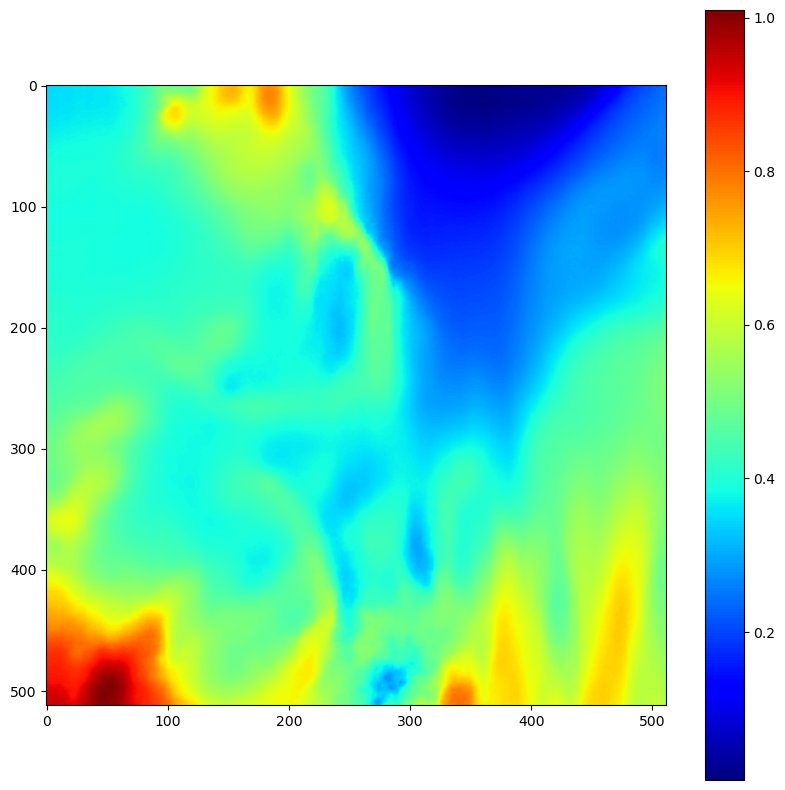

In [2]:
array_sr = np.load('Result/Mines/Benga_Mine/20170701.npy')

fig = plt.figure(figsize=(10, 10))
im = plt.imshow(array_sr, cmap='jet')
plt.colorbar(im)

In [3]:
array_sr.shape

(512, 512)

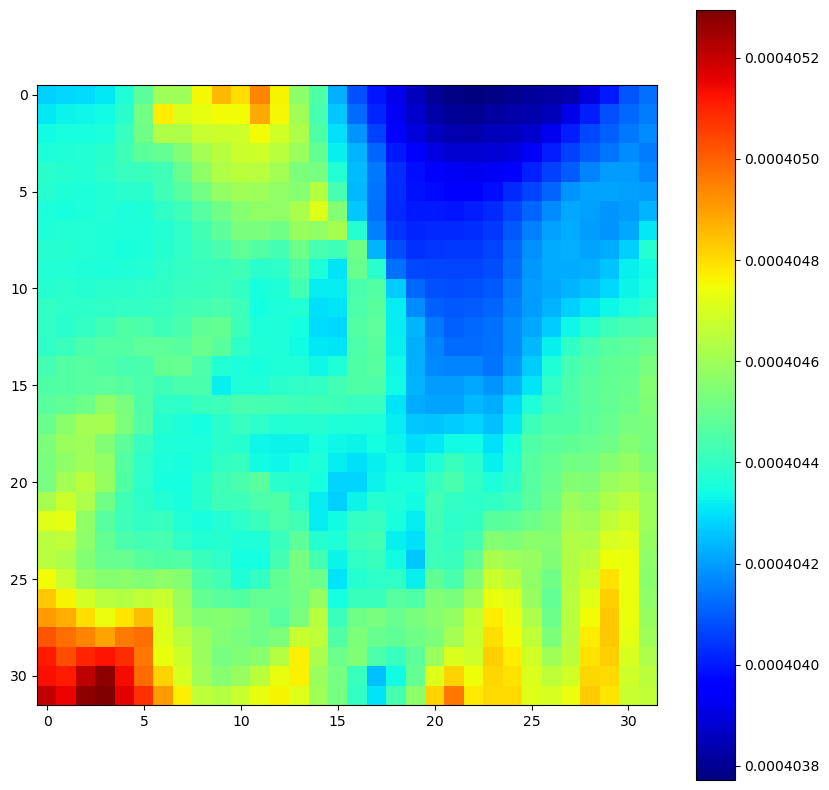

In [6]:
array_lr = np.load('Input/Mines/Benga_Mine/20170701.npy')

fig = plt.figure(figsize=(10, 10))
im = plt.imshow(array_lr, cmap='jet')
plt.colorbar(im)